# E-Commerce Sales & Customer Analysis

## Executive Summary

This project analyzes **500 e-commerce orders** containing **1,050 units sold** and **35.87 million in recorded gross revenue**. The analysis focuses on customer behavior, product performance, sales trends, payment methods, order status, and geographic performance.

Key findings include:

* **Laptop** is the top-performing product, generating **15.71 million** in revenue.
* **Islamabad** is the highest-revenue city, generating **6.72 million**.
* **Online payment** is the most-used payment method, with **168 orders** and **13.35 million** in revenue.
* **High-value customers** have an average revenue of approximately **451,422** and an average AOV of **110,463**.
* **November** recorded the highest monthly revenue at **3.56 million**, while **July** recorded the lowest at **2.16 million**.
* **June** had the highest monthly AOV at approximately **97,826**.
* The overall **AOV is 71,744**.
* **86.8%** of orders were completed, while **7.4% were cancelled** and **5.8% were returned**.
* **3.66 million** of recorded revenue is associated with cancelled or returned orders, highlighting the importance of distinguishing gross revenue from completed revenue.
* The correlation between customer AOV and total revenue is approximately **0.655**, indicating a moderate positive relationship.

Overall, the analysis suggests that the business should focus on its high-performing **Laptop and Mobile** categories, retain high-value customers, strengthen key markets such as **Islamabad and Multan**, optimize online purchasing, and investigate the causes of cancellations and returns.


## Business Questions

The analysis aims to answer the following business questions:

1. **What is the overall sales performance of the business?**

   * How many orders and units were sold?
   * What is the total revenue and average order value?

2. **Which products perform best?**

   * Which products generate the highest revenue?
   * Which products have the highest sales volume?
   * Which products generate the highest revenue per unit?

3. **Who are the most valuable customers?**

   * Which customers generate the highest revenue?
   * Which customers have the highest average order value?
   * How do customer segments differ in revenue and AOV?

4. **How does sales performance change over time?**

   * Which months generate the highest and lowest revenue?
   * How does monthly AOV change?
   * Which products drive revenue in different months?

5. **Which payment methods are most popular and valuable?**

   * Which payment method generates the most revenue?
   * Which payment method has the highest number of orders?

6. **What is the quality of the order pipeline?**

   * What percentage of orders are completed?
   * What are the cancellation and return rates?
   * How much recorded revenue is associated with cancelled or returned orders?

7. **Which cities are the strongest markets?**

   * Which cities generate the highest revenue?
   * How does order volume compare across cities?
   * Which cities have the highest AOV?

8. **What actionable business recommendations can be derived from the analysis?**


## Dataset Overview

The dataset contains **500 e-commerce order records** covering sales transactions across multiple products, customers, cities, payment methods, and order statuses.

### Dataset Columns

| Column           | Description                          |
| ---------------- | ------------------------------------ |
| `Order_ID`       | Unique identifier for each order     |
| `Order_Date`     | Date on which the order was placed   |
| `Customer_ID`    | Unique identifier for each customer  |
| `Product`        | Product purchased                    |
| `Quantity`       | Number of units purchased            |
| `Payment_Method` | Payment method used for the order    |
| `Order_Status`   | Current status of the order          |
| `Customer_Name`  | Customer name                        |
| `Gender`         | Customer gender                      |
| `Age`            | Customer age                         |
| `City`           | Customer's city                      |
| `Unit_Price`     | Price per unit                       |
| `Revenue`        | Revenue generated by the transaction |
| `Month`          | Month associated with the order      |

### Dataset Summary

* **Total Orders:** 500
* **Total Quantity Sold:** 1,050
* **Gross Revenue:** 35.87M
* **Completed Revenue:** 32.21M
* **Overall AOV:** 71,744.20
* **Order Period:** January–December 2026

The dataset provides sufficient information to analyze **sales performance, customer behavior, product performance, time trends, payment preferences, order outcomes, and geographic performance**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Cleaning

### 1. Load Dataset

In [2]:
df=pd.read_csv("ecommerce_sales_data_corrected.csv")

### 2. Initial Data Inspection

In [3]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Quantity,Payment_Method,Order_Status,Customer_Name,Gender,Age,City,Unit_Price,Revenue
0,ORD10174,2026-01-13,C1071,Mobile,3,Cash,Completed,Customer_071,Male,44.0,Lahore,52100.0,156300.0
1,ORD10275,2026-08-14,C1074,Laptop,2,Card,Returned,Customer_074,Male,19.0,Islamabad,84300.0,168600.0
2,ORD10491,2026-11-15,C1009,Keyboard,1,Bank Transfer,Cancelled,Customer_009,Female,45.0,Peshawar,4300.0,4300.0
3,ORD10073,2026-06-24,C1010,Headphones,3,Cash,Cancelled,Customer_010,Female,31.0,Rawalpindi,8100.0,24300.0
4,ORD10306,2026-08-25,C1105,Monitor,4,Online,Completed,Customer_105,Male,39.0,Rawalpindi,29000.0,116000.0


In [4]:
df.tail()

,Order_ID,Order_Date,Customer_ID,Product,Quantity,Payment_Method,Order_Status,Customer_Name,Gender,Age,City,Unit_Price,Revenue
500,ORD10107,2026-07-18,C1101,Office Chair,2,Online,Completed,Customer_101,Female,29.0,Faisalabad,22500.0,45000.0
501,ORD10271,2026-02-28,C1006,Desk,5,Card,Completed,Customer_006,Female,43.0,Rawalpindi,29000.0,145000.0
502,ORD10349,2026-04-21,C1146,Laptop,1,Online,Completed,Customer_146,Male,22.0,Lahore,90400.0,90400.0
503,ORD10436,2026-11-13,C1100,Laptop,3,Cash,Completed,Customer_100,Male,52.0,Multan,85200.0,255600.0
504,ORD10103,2026-09-14,C1150,Mobile,2,Online,Completed,Customer_150,Female,53.0,Lahore,52900.0,105800.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_ID        505 non-null    object 
 1   Order_Date      505 non-null    object 
 2   Customer_ID     505 non-null    object 
 3   Product         505 non-null    object 
 4   Quantity        505 non-null    int64  
 5   Payment_Method  501 non-null    object 
 6   Order_Status    505 non-null    object 
 7   Customer_Name   505 non-null    object 
 8   Gender          502 non-null    object 
 9   Age             500 non-null    float64
 10  City            501 non-null    object 
 11  Unit_Price      505 non-null    float64
 12  Revenue         505 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 51.4+ KB


In [6]:
df.describe()

,Quantity,Age,Unit_Price,Revenue
count,505.000000,500.000000,505.000000,505.000000
mean,2.097030,38.698000,34791.089109,71182.772277
std,1.175347,12.489466,29841.078733,76547.584279
min,1.000000,18.000000,2300.000000,2300.000000
25%,1.000000,27.000000,7800.000000,14100.000000
50%,2.000000,40.000000,28000.000000,52200.000000
75%,3.000000,48.000000,55900.000000,102600.000000
max,5.000000,60.000000,91800.000000,440000.000000


### 3. Missing Value Analysis

In [7]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Product           0
Quantity          0
Payment_Method    4
Order_Status      0
Customer_Name     0
Gender            3
Age               5
City              4
Unit_Price        0
Revenue           0
dtype: int64

### 4. Duplicate Analysis

In [8]:
df.duplicated().sum()

np.int64(5)

### 5. Data Type Inspection

In [9]:
df.dtypes

Order_ID           object
Order_Date         object
Customer_ID        object
Product            object
Quantity            int64
Payment_Method     object
Order_Status       object
Customer_Name      object
Gender             object
Age               float64
City               object
Unit_Price        float64
Revenue           float64
dtype: object

In [10]:
df[df.isnull().any(axis=1)]

,Order_ID,Order_Date,Customer_ID,Product,Quantity,Payment_Method,Order_Status,Customer_Name,Gender,Age,City,Unit_Price,Revenue
69,ORD10456,2026-12-19,C1104,Headphones,2,Cash,Cancelled,Customer_104,NaN,28.0,Lahore,7900.0,15800.0
97,ORD10412,2026-08-28,C1012,Mobile,2,Cash,Completed,Customer_012,NaN,32.0,Karachi,59000.0,118000.0
143,ORD10212,2026-12-07,C1031,Laptop,2,Online,Completed,Customer_031,Female,NaN,Faisalabad,85200.0,170400.0
156,ORD10468,2026-05-28,C1138,Mobile,1,Online,Returned,Customer_138,Male,54.0,NaN,57300.0,57300.0
187,ORD10142,2026-01-30,C1141,Mouse,2,Card,Completed,Customer_141,Female,NaN,Karachi,2600.0,5200.0
191,ORD10169,2026-02-18,C1144,Mobile,3,NaN,Completed,Customer_144,Male,36.0,Multan,56700.0,170100.0
234,ORD10090,2026-01-04,C1145,Mouse,2,Card,Completed,Customer_145,Female,NaN,Karachi,2400.0,4800.0
263,ORD10124,2026-10-20,C1048,Mobile,2,Online,Completed,Customer_048,Female,22.0,NaN,51500.0,103000.0
294,ORD10370,2026-05-20,C1004,Laptop,2,Online,Completed,Customer_004,NaN,26.0,Multan,85400.0,170800.0
315,ORD10437,2026-05-16,C1024,Mobile,1,NaN,Cancelled,Customer_024,Female,24.0,Multan,52300.0,52300.0


In [11]:
df.groupby("Gender")["Age"].mean()

Gender
Female    38.171806
Male      39.251852
Name: Age, dtype: float64

In [12]:
df=df.copy()
df["Age"]=df["Age"].fillna(39.0)

Fill the age missing values with average male and female age i.e approximate 39.

In [13]:
df["Gender"]=df["Gender"].fillna("Unknown")
df["City"]=df["City"].fillna("Unknown")
df["Payment_Method"]=df["Payment_Method"].fillna("Unknown")

In [14]:
df.isnull().sum().sum()

np.int64(0)

Missing values in Gender,City and Payment_Method were replaced with "Unknown" rather than being deleted or guessed. Since all three  variables are categorical and the actual values cannot be reliably inferred, using an "Unknown" category preserves the records while avoiding inaccurate assumptions.

In [15]:
df[df.duplicated()]

,Order_ID,Order_Date,Customer_ID,Product,Quantity,Payment_Method,Order_Status,Customer_Name,Gender,Age,City,Unit_Price,Revenue
49,ORD10001,2026-09-14,C1092,Headphones,2,Bank Transfer,Completed,Customer_092,Female,28.0,Islamabad,8600.0,17200.0
93,ORD10003,2026-11-29,C1078,Office Chair,1,Online,Completed,Customer_078,Male,42.0,Faisalabad,20800.0,20800.0
158,ORD10004,2026-10-03,C1051,Headphones,2,Card,Completed,Customer_051,Male,40.0,Faisalabad,7400.0,14800.0
462,ORD10002,2026-05-20,C1134,Keyboard,3,Cash,Completed,Customer_134,Female,60.0,Islamabad,4600.0,13800.0
496,ORD10005,2026-04-01,C1087,Headphones,1,Card,Completed,Customer_087,Male,48.0,Faisalabad,8600.0,8600.0


In [16]:
df=df.drop_duplicates()

In [17]:
df.duplicated().sum()

np.int64(0)

### 6. Order Status Consistency Check

In [18]:
df.groupby("Order_Status")["Order_ID"].count()

Order_Status
Cancelled      35
Cancelled       2
Completed     432
Returned       27
completed       2
returned        2
Name: Order_ID, dtype: int64

In [19]:
df["Order_Status"]=df["Order_Status"].str.strip().str.title()

In [20]:
df["Order_Status"].value_counts()

Order_Status
Completed    434
Cancelled     37
Returned      29
Name: count, dtype: int64

In [21]:
df.dtypes

Order_ID           object
Order_Date         object
Customer_ID        object
Product            object
Quantity            int64
Payment_Method     object
Order_Status       object
Customer_Name      object
Gender             object
Age               float64
City               object
Unit_Price        float64
Revenue           float64
dtype: object

In [22]:
df["Order_Date"]=pd.to_datetime(df["Order_Date"])

In [23]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [24]:
df["Revenue"]=df["Quantity"]*df["Unit_Price"]

In [25]:
df[["Quantity","Unit_Price","Revenue"]].head()

,Quantity,Unit_Price,Revenue
0,3,52100.0,156300.0
1,2,84300.0,168600.0
2,1,4300.0,4300.0
3,3,8100.0,24300.0
4,4,29000.0,116000.0


## Business KPIs

#### KPI 1 — Total Revenue

In [26]:
total_revenue=df["Revenue"].sum()
total_revenue

np.float64(35872100.0)

#### KPI 2 — Total Orders

In [27]:
total_orders=df["Order_ID"].nunique()
total_orders

500

#### KPI 3 — Total Quantity Sold

In [28]:
total_quantity=df["Quantity"].sum()
total_quantity

np.int64(1050)

#### KPI 4 — Average Order Value

In [29]:
Average_OrderValue=total_revenue/total_orders
Average_OrderValue

np.float64(71744.2)

#### KPI 5 — Unique Customers

In [30]:
unique_customers=df["Customer_ID"].nunique()
unique_customers

146

#### KPI 6 — Cancellation Rate

In [31]:
cancelled_orders = (df["Order_Status"] == "Cancelled").sum()
cancelled_orders

np.int64(37)

In [32]:
cancellation_rate = (cancelled_orders / total_orders) * 100
cancellation_rate

np.float64(7.3999999999999995)

#### KPI 7 — Revenue by Product

In [33]:
revenue_by_product=df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
revenue_by_product

Product
Laptop          15707100.0
Mobile           9845500.0
Desk             3536700.0
Monitor          3298900.0
Headphones       1368400.0
Office Chair     1316800.0
Keyboard          556600.0
Mouse             242100.0
Name: Revenue, dtype: float64

Highest Revenue by Product= Laptop (15668600.0)
Lowest Revenue by Product= Mouse (289800.0)

#### KPI 8 __ Revenue by City

In [34]:
revenue_by_city=df.groupby("City")["Revenue"].sum().sort_values(ascending=False)
revenue_by_city

City
Islamabad     6717200.0
Multan        6625500.0
Karachi       5559400.0
Faisalabad    4721300.0
Lahore        4403400.0
Rawalpindi    4272900.0
Peshawar      3368300.0
Unknown        204100.0
Name: Revenue, dtype: float64

#### KPI 9 __ Payment_Method

In [35]:
revenue_by_payment=df.groupby("Payment_Method")["Revenue"].sum().sort_values(ascending=False)
revenue_by_payment

Payment_Method
Online           13349500.0
Card              9872300.0
Cash              9048900.0
Bank Transfer     3225800.0
Unknown            375600.0
Name: Revenue, dtype: float64

#### KPI 10 __ Order_Status Analysis


In [36]:
order_status_count=df["Order_Status"].value_counts(dropna=False)
order_status_count

Order_Status
Completed    434
Cancelled     37
Returned      29
Name: count, dtype: int64

In [37]:
revenue_by_status=df.groupby("Order_Status")["Revenue"].sum().sort_values(ascending=False)
revenue_by_status

Order_Status
Completed    32209100.0
Cancelled     2247000.0
Returned      1416000.0
Name: Revenue, dtype: float64

#### KPI 11 __ Monthly Revenue

In [38]:
df["Month"]=df["Order_Date"].dt.month

In [39]:
monthly_revenue=df.groupby("Month")["Revenue"].sum()
monthly_revenue

Month
1     3224200.0
2     3147600.0
3     2213200.0
4     2924200.0
5     3029300.0
6     3423900.0
7     2155100.0
8     2877900.0
9     3120300.0
10    3048600.0
11    3561800.0
12    3146000.0
Name: Revenue, dtype: float64

#### KPI 12 __ Quantity by Product

In [40]:
quantity_by_product=df.groupby("Product")["Quantity"].sum().sort_values(ascending=False)
quantity_by_product

Product
Laptop          184
Mobile          181
Headphones      170
Desk            126
Keyboard        122
Monitor         110
Mouse            97
Office Chair     60
Name: Quantity, dtype: int64

### KPI 13 __ Orders by Product

In [41]:
order_by_product=df.groupby("Product")["Order_ID"].count()
order_by_product

Product
Desk            55
Headphones      81
Keyboard        61
Laptop          94
Mobile          89
Monitor         48
Mouse           44
Office Chair    28
Name: Order_ID, dtype: int64

## Phase 3 — Data Visualization

### Chart 1 — Revenue by Product:

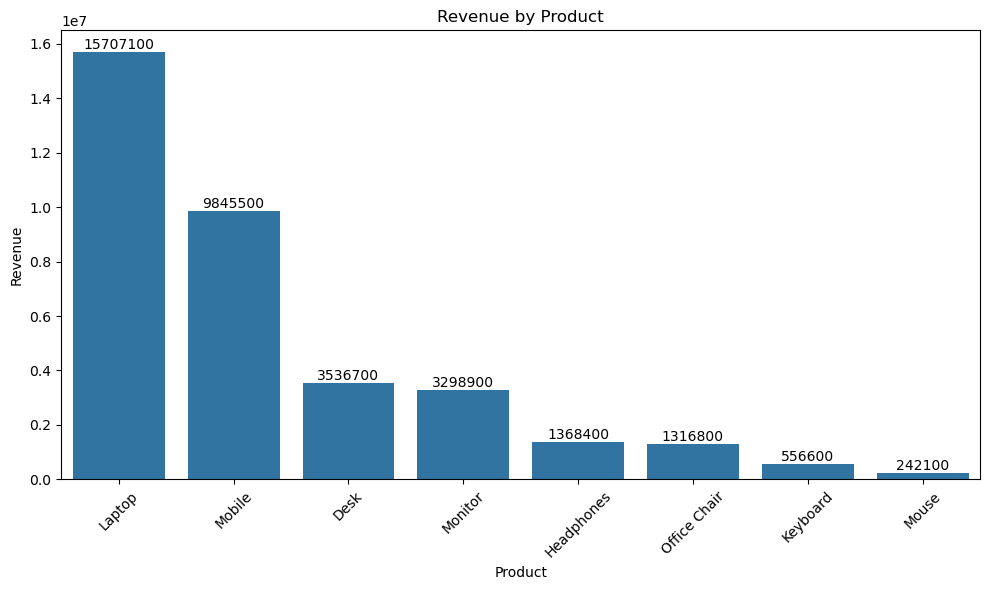

In [42]:
plt.figure(figsize=(10,6))

ax=sns.barplot(
    x=revenue_by_product.index,
    y=revenue_by_product.values
)

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

### Chart 2 __ Quantity by Product:

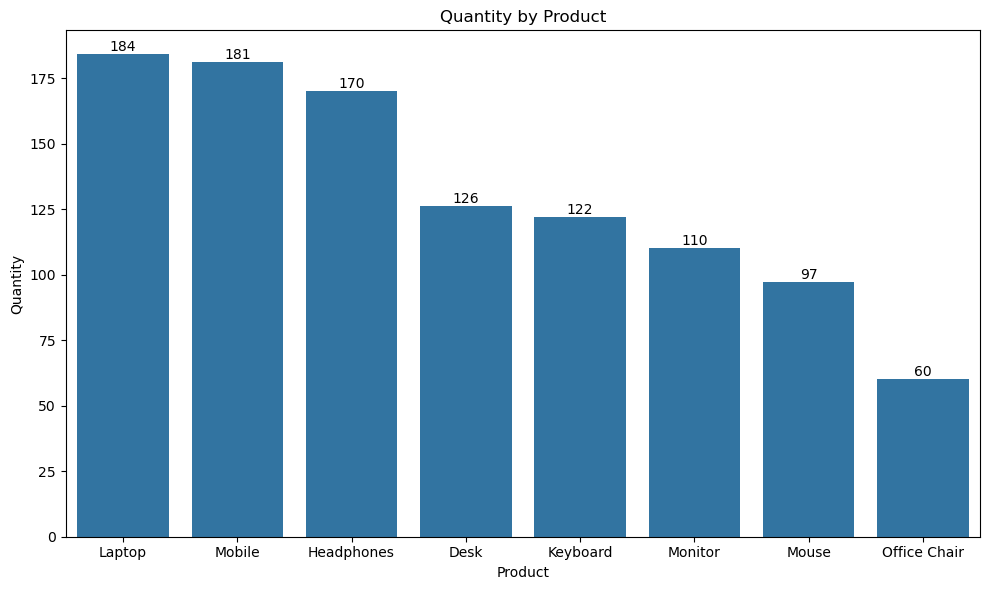

In [43]:
plt.figure(figsize=(10,6))

ax=sns.barplot(
    x=quantity_by_product.index,
    y=quantity_by_product.values
)

plt.title("Quantity by Product")
plt.xlabel("Product")
plt.ylabel("Quantity")


for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
    
plt.tight_layout()
plt.show()

### Chart 3 __ Revenue by City:

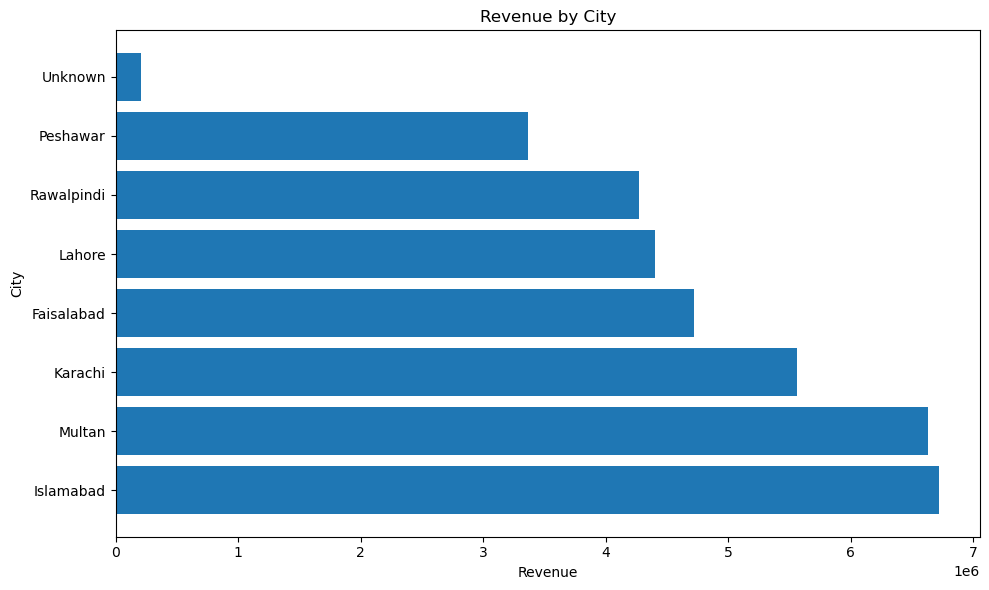

In [44]:
plt.figure(figsize=(10,6))

plt.barh(revenue_by_city.index,revenue_by_city.values)
plt.title("Revenue by City")
plt.ylabel("City")
plt.xlabel("Revenue")
plt.tight_layout()

plt.show()

### Chart 4 __ Revenue by Payment Method:

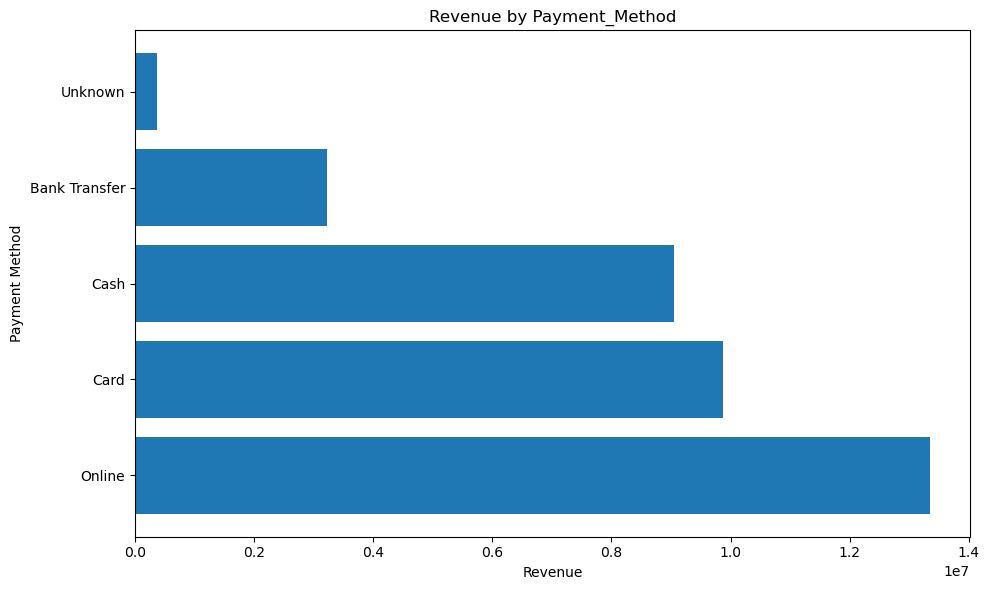

In [45]:
plt.figure(figsize=(10,6))

plt.barh(revenue_by_payment.index,revenue_by_payment.values)
plt.title("Revenue by Payment_Method")
plt.ylabel("Payment Method")
plt.xlabel("Revenue")
plt.tight_layout()

plt.show()

### Chart 5 ___ Monthly Revenue Trend:

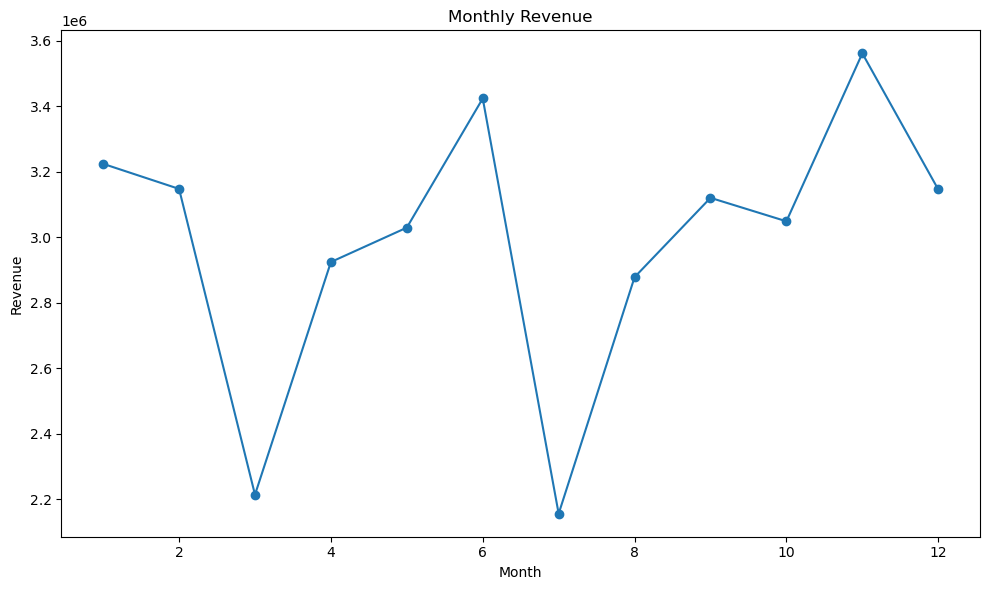

In [46]:
plt.figure(figsize=(10,6))

plt.plot(monthly_revenue.index,monthly_revenue.values,marker="o")
plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.tight_layout()

plt.show()

### Chart 06 ___ Comparison of highest-quantity vs highest-revenue product

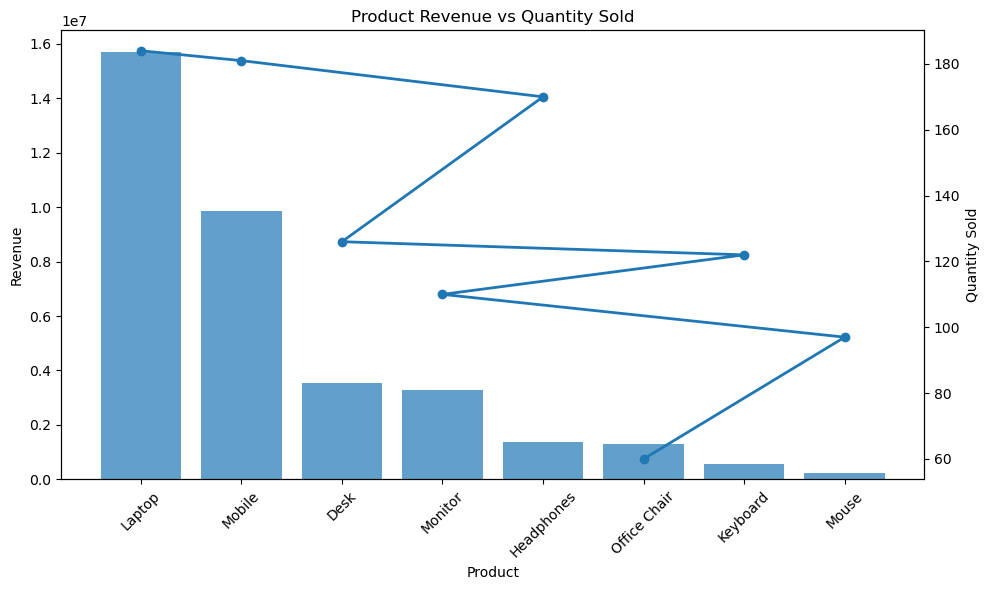

In [47]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Revenue
ax1.bar(
    revenue_by_product.index,
    revenue_by_product.values,
    alpha=0.7
)

ax1.set_xlabel("Product")
ax1.set_ylabel("Revenue")
ax1.tick_params(axis="x", rotation=45)

# Quantity
ax2 = ax1.twinx()

ax2.plot(
    quantity_by_product.index,
    quantity_by_product.values,
    marker="o",
    linewidth=2
)

ax2.set_ylabel("Quantity Sold")

plt.title("Product Revenue vs Quantity Sold")
plt.tight_layout()
plt.show()

Above chart revealed that the Laptop is generating the highest revenue while the highest quantity sold is for the mobile.
The reason is that the laptop has higher price relative to the mobile and revenue depends on both the price and quantity.

## Customer Analysis

In [48]:
customer_summary = (
    df.groupby("Customer_ID")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum")
      )
)

customer_summary["AOV"] = (
    customer_summary["Total_Revenue"] /
    customer_summary["Total_Orders"]
)

customer_summary.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Customer_ID,,,,
C1116,9,21,999700.0,111077.777778
C1141,6,14,867300.0,144550.000000
C1083,5,18,810100.0,162020.000000
C1023,7,16,741400.0,105914.285714
C1012,8,17,729000.0,91125.000000
C1127,3,8,720200.0,240066.666667
C1024,8,20,700800.0,87600.000000
C1112,6,14,673900.0,112316.666667
C1144,5,15,607500.0,121500.000000


### Top 10 customers by Revenue

In [49]:
customer_summary.sort_values("Total_Revenue", ascending=False).head(10)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Customer_ID,,,,
C1116,9,21,999700.0,111077.777778
C1141,6,14,867300.0,144550.000000
C1083,5,18,810100.0,162020.000000
C1023,7,16,741400.0,105914.285714
C1012,8,17,729000.0,91125.000000
C1127,3,8,720200.0,240066.666667
C1024,8,20,700800.0,87600.000000
C1112,6,14,673900.0,112316.666667
C1144,5,15,607500.0,121500.000000


### Top 10 customers by Orders

In [50]:
customer_summary.sort_values("Total_Orders", ascending=False).head(10)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Customer_ID,,,,
C1116,9,21,999700.0,111077.777778
C1012,8,17,729000.0,91125.000000
C1024,8,20,700800.0,87600.000000
C1054,8,13,438800.0,54850.000000
C1046,7,16,299200.0,42742.857143
C1039,7,14,334000.0,47714.285714
C1023,7,16,741400.0,105914.285714
C1004,7,13,360400.0,51485.714286
C1025,6,9,305000.0,50833.333333


In [51]:
customer_summary.sort_values("AOV", ascending=False).head(10)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Customer_ID,,,,
C1127,3,8,720200.0,240066.666667
C1042,2,5,429400.0,214700.000000
C1020,2,5,387900.0,193950.000000
C1068,2,4,351200.0,175600.000000
C1089,3,9,511800.0,170600.000000
C1031,1,2,170400.0,170400.000000
C1021,3,9,503600.0,167866.666667
C1013,1,2,165400.0,165400.000000
C1001,3,7,489100.0,163033.333333


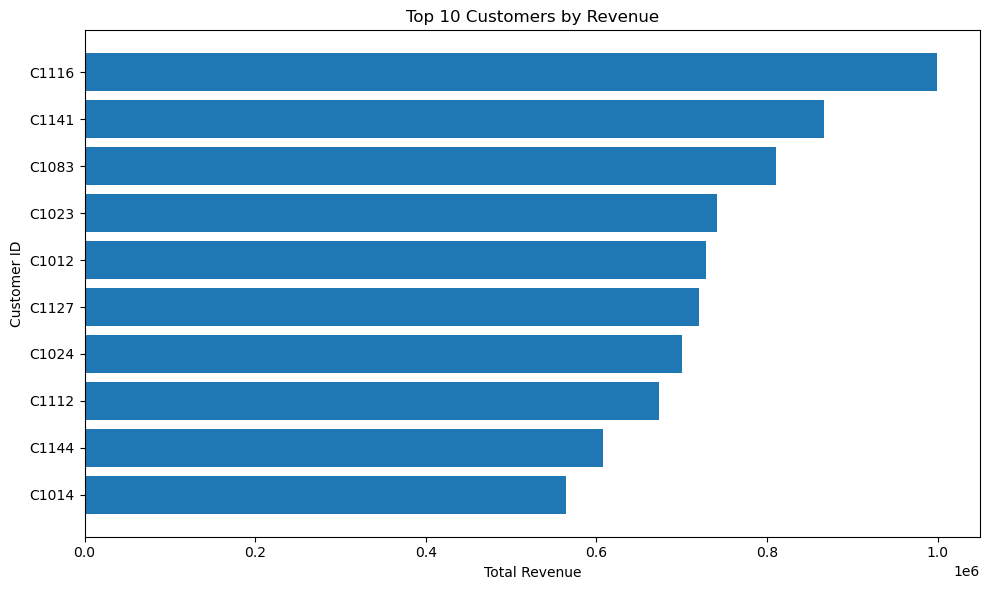

In [52]:
top_10_revenue = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
    .sort_values("Total_Revenue")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_revenue.index.astype(str),
    top_10_revenue["Total_Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

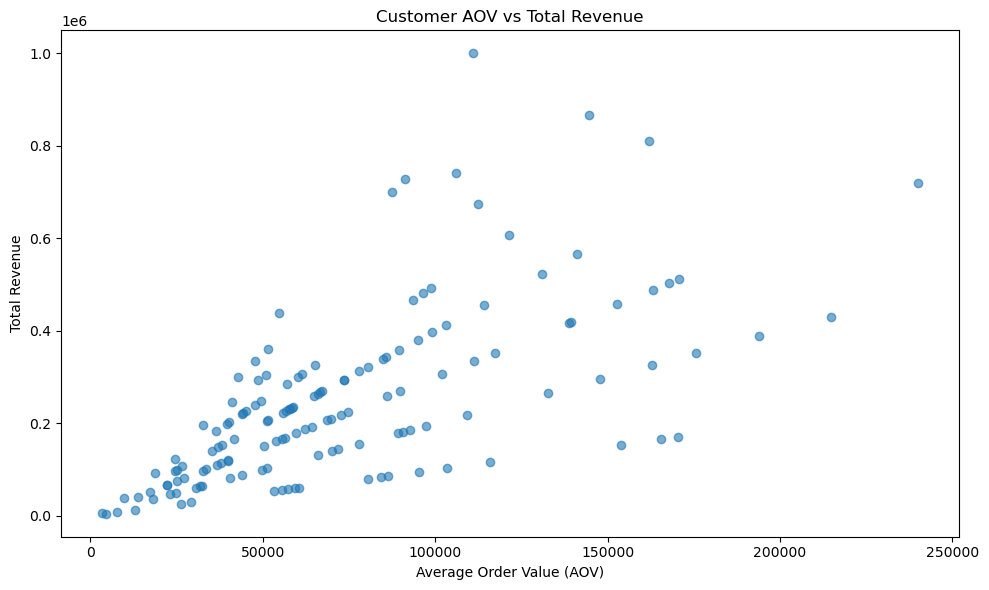

In [53]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_summary["AOV"],
    customer_summary["Total_Revenue"],
    alpha=0.6
)

plt.title("Customer AOV vs Total Revenue")
plt.xlabel("Average Order Value (AOV)")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [54]:
customer_summary["AOV"].corr(
    customer_summary["Total_Revenue"]
)

np.float64(0.6546680109542454)

Insight: A moderate positive correlation (r = 0.655) was observed between Average Order Value and Total Revenue. This suggests that customers who spend more per order generally contribute more overall revenue, although purchase frequency also plays an important role.

## Customer Segmentation

In [55]:
customer_summary.head()

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Customer_ID,,,,
C1001,3,7,489100.0,163033.333333
C1003,3,4,151500.0,50500.000000
C1004,7,13,360400.0,51485.714286
C1005,4,9,205500.0,51375.000000
C1006,5,17,306400.0,61280.000000


In [56]:
customer_summary["Customer_Segment"]=pd.qcut(
    customer_summary["Total_Revenue"],
    q=3,
    labels=["Low Value","Medium Value","High Value"]
)

customer_summary.head()

,Total_Orders,Total_Quantity,Total_Revenue,AOV,Customer_Segment
Customer_ID,,,,,
C1001,3,7,489100.0,163033.333333,High Value
C1003,3,4,151500.0,50500.000000,Medium Value
C1004,7,13,360400.0,51485.714286,High Value
C1005,4,9,205500.0,51375.000000,Medium Value
C1006,5,17,306400.0,61280.000000,High Value


In [57]:
customer_summary["Customer_Segment"].value_counts()

Customer_Segment
Low Value       49
High Value      49
Medium Value    48
Name: count, dtype: int64

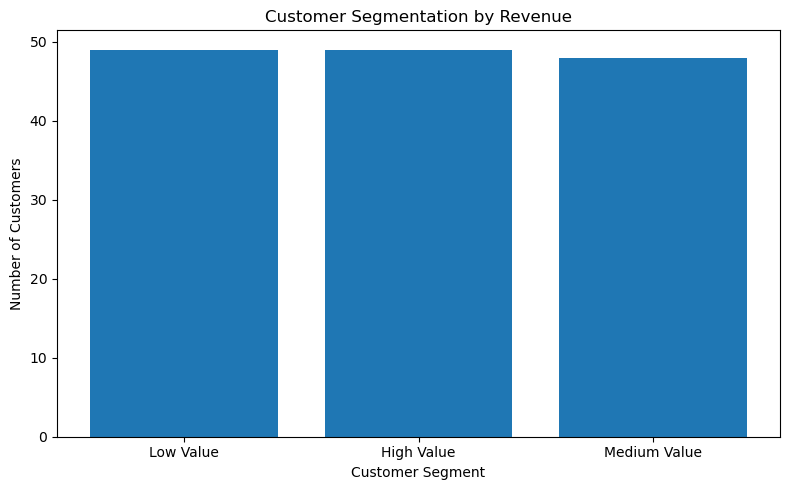

In [58]:
segment_counts=customer_summary["Customer_Segment"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Segmentation by Revenue")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [59]:
segment_analysis = customer_summary.groupby(
    "Customer_Segment",
    observed=True
)[
    ["Total_Orders", "Total_Quantity", "Total_Revenue", "AOV"]
].mean()

segment_analysis

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Customer_Segment,,,,
Low Value,2.244898,3.918367,77418.367347,40874.387755
Medium Value,3.500000,7.166667,207477.083333,68628.402778
High Value,4.530612,10.489796,451422.448980,110463.059605


## Key insights

### 1. High-value customers are substantially more valuable

The average revenue of High Value customers is 451,422, compared with only 77,418 for Low Value customers.

That's about 5.8× higher average revenue.

### 2. High-value customers purchase more frequently

High Value customers average 4.53 orders, compared with 2.24 orders for Low Value customers.

So revenue isn't coming only from larger orders — purchase frequency also matters.

### 3. High-value customers have much higher AOV

Their average AOV is 110,463, compared with 40,874 for Low Value customers.

That's about 2.7× higher AOV.

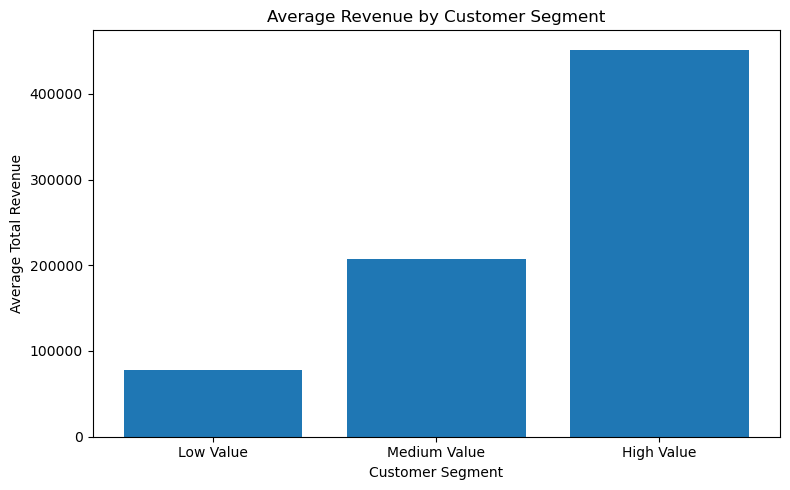

In [60]:
segment_revenue = (
    customer_summary
    .groupby("Customer_Segment", observed=True)["Total_Revenue"]
    .mean()
)

plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue.index,
    segment_revenue.values
)

plt.title("Average Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Total Revenue")

plt.tight_layout()
plt.show()

Customer Segmentation Insight: High-value customers generate substantially more revenue than medium- and low-value customers. They also place more orders and have a higher average order value, indicating that both purchase frequency and spending per order contribute to customer value.

## Product Analysis

In [61]:
product_summary=(
    df.groupby("Product")
        .agg(
            Total_Orders=("Order_ID","nunique"),
             Total_Quantity=("Quantity","sum"),
             Total_Revenue=("Revenue","sum")
        )
)

product_summary.head()
    

,Total_Orders,Total_Quantity,Total_Revenue
Product,,,
Desk,55,126,3536700.0
Headphones,81,170,1368400.0
Keyboard,61,122,556600.0
Laptop,94,184,15707100.0
Mobile,89,181,9845500.0


In [62]:
top_10_products=(
    product_summary
    .sort_values("Total_Revenue",ascending=False)
    .head()
)

top_10_products   

,Total_Orders,Total_Quantity,Total_Revenue
Product,,,
Laptop,94,184,15707100.0
Mobile,89,181,9845500.0
Desk,55,126,3536700.0
Monitor,48,110,3298900.0
Headphones,81,170,1368400.0


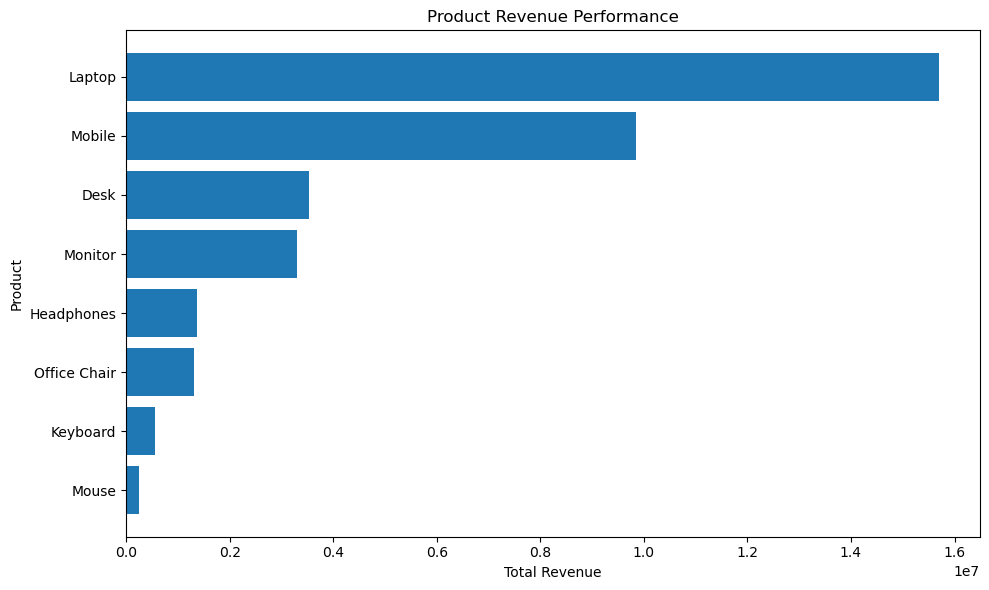

In [63]:
product_revenue_plot = product_summary.sort_values("Total_Revenue")

plt.figure(figsize=(10, 6))

plt.barh(
    product_revenue_plot.index,
    product_revenue_plot["Total_Revenue"]
)

plt.title("Product Revenue Performance")
plt.xlabel("Total Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [64]:
product_summary.sort_values(
    "Total_Quantity",
    ascending=False
)

,Total_Orders,Total_Quantity,Total_Revenue
Product,,,
Laptop,94,184,15707100.0
Mobile,89,181,9845500.0
Headphones,81,170,1368400.0
Desk,55,126,3536700.0
Keyboard,61,122,556600.0
Monitor,48,110,3298900.0
Mouse,44,97,242100.0
Office Chair,28,60,1316800.0


## Key insights

### 1. Laptop is the strongest product.

It has the highest:

#### Orders: 94

#### Quantity sold: 184

#### Revenue: 15.71M

So Laptop is clearly the major revenue driver.

### 2. Mobile is also a major revenue contributor.

Mobile has almost the same sales volume as Laptop (181 vs. 184 units) but generates substantially less revenue (9.85M vs. 15.71M).

This suggests Laptop has a much higher revenue per unit.

### 3. Headphones are interesting.

Headphones sold 170 units, almost as many as Mobile, but generated only 1.37M.

That's a great example of why quantity alone shouldn't be used to judge product performance.

### 4. Office Chair has relatively low volume but relatively high revenue.

Only 60 units were sold, yet revenue was 1.32M. This indicates a much higher value per unit.

In [65]:
product_summary["Revenue_per_Unit"] = (
    product_summary["Total_Revenue"] /
    product_summary["Total_Quantity"]
)

product_summary.sort_values(
    "Revenue_per_Unit",
    ascending=False
)

,Total_Orders,Total_Quantity,Total_Revenue,Revenue_per_Unit
Product,,,,
Laptop,94,184,15707100.0,85364.673913
Mobile,89,181,9845500.0,54395.027624
Monitor,48,110,3298900.0,29990.000000
Desk,55,126,3536700.0,28069.047619
Office Chair,28,60,1316800.0,21946.666667
Headphones,81,170,1368400.0,8049.411765
Keyboard,61,122,556600.0,4562.295082
Mouse,44,97,242100.0,2495.876289


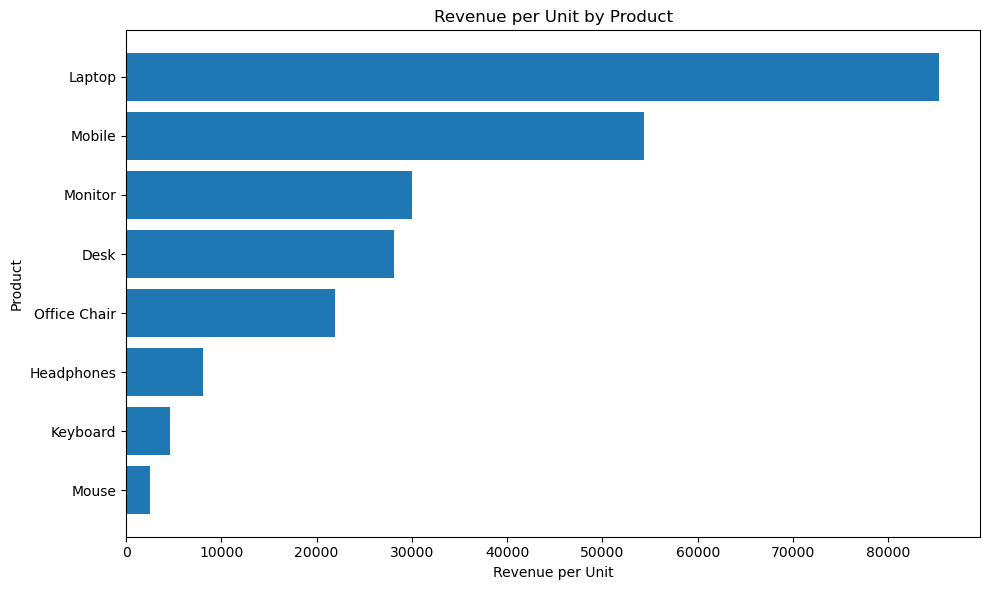

In [66]:
revenue_per_unit = product_summary.sort_values(
    "Revenue_per_Unit"
)

plt.figure(figsize=(10, 6))

plt.barh(
    revenue_per_unit.index,
    revenue_per_unit["Revenue_per_Unit"]
)

plt.title("Revenue per Unit by Product")
plt.xlabel("Revenue per Unit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Key business insights

### 1. Laptop is the highest-value product.

Laptop generates approximately 85,365 revenue per unit, far above every other product.

This explains why it dominates total revenue even though its quantity sold is only slightly higher than Mobile.

### 2. Mobile is the second-highest-value product.

Mobile generates about 54,395 per unit, while selling almost as many units as Laptop.

This makes Laptop and Mobile your strongest products from both volume and value perspectives.

### 3. Monitor and Desk are interesting mid-range products.

Both have relatively high revenue per unit:

#### Monitor → 29,990

#### Desk → 28,069

However, their sales volumes are much lower than Laptop and Mobile.

### 4. Headphones sell well but generate relatively little revenue per unit.

Headphones sold 170 units, but revenue per unit is only about 8,049.

This is a classic example of a high-volume, lower-value product.

### 5. Mouse has the lowest revenue per unit.

Mouse generates only about 2,496 per unit, despite selling 97 units.


## Average Order Value by Product.

In [67]:
product_summary["AOV"] = (
    product_summary["Total_Revenue"] /
    product_summary["Total_Orders"]
)

product_summary.sort_values(
    "AOV",
    ascending=False
)

,Total_Orders,Total_Quantity,Total_Revenue,Revenue_per_Unit,AOV
Product,,,,,
Laptop,94,184,15707100.0,85364.673913,167096.808511
Mobile,89,181,9845500.0,54395.027624,110623.595506
Monitor,48,110,3298900.0,29990.000000,68727.083333
Desk,55,126,3536700.0,28069.047619,64303.636364
Office Chair,28,60,1316800.0,21946.666667,47028.571429
Headphones,81,170,1368400.0,8049.411765,16893.827160
Keyboard,61,122,556600.0,4562.295082,9124.590164
Mouse,44,97,242100.0,2495.876289,5502.272727


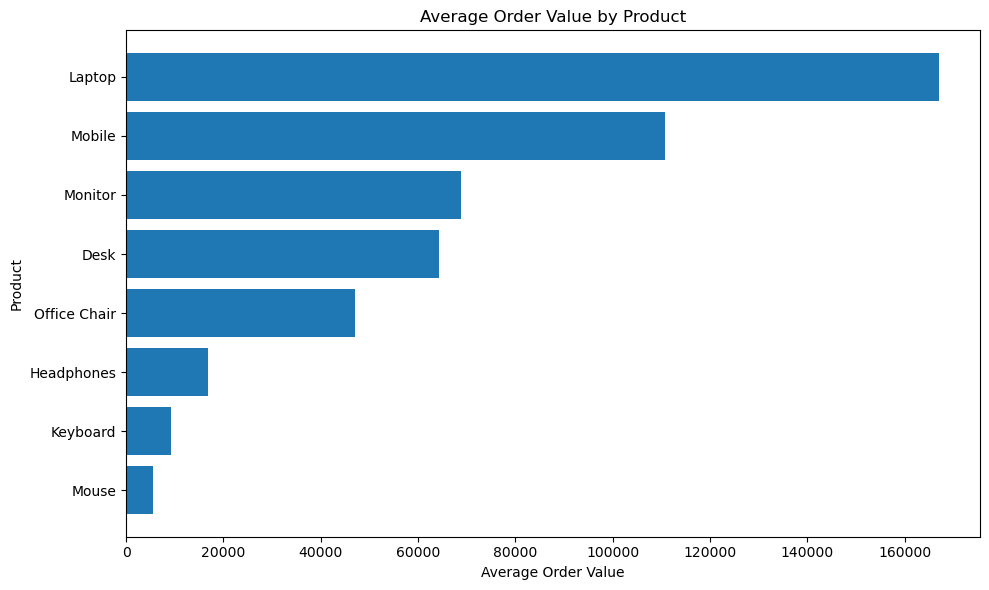

In [68]:
product_aov = product_summary.sort_values("AOV")

plt.figure(figsize=(10, 6))

plt.barh(
    product_aov.index,
    product_aov["AOV"]
)

plt.title("Average Order Value by Product")
plt.xlabel("Average Order Value")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

## Monthly Sales Summary

In [69]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Order_Date"].dtype

dtype('<M8[ns]')

In [70]:
monthly_sales=(
    df.groupby(df["Order_Date"].dt.to_period("M"))
    .agg(
        Total_Orders=("Order_ID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum")
    )
      
)

monthly_sales

,Total_Orders,Total_Quantity,Total_Revenue
Order_Date,,,
2026-01,37,80,3224200.0
2026-02,46,104,3147600.0
2026-03,38,72,2213200.0
2026-04,42,88,2924200.0
2026-05,47,93,3029300.0
2026-06,35,88,3423900.0
2026-07,33,69,2155100.0
2026-08,44,85,2877900.0
2026-09,42,86,3120300.0


In [71]:
monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.head()

,Total_Orders,Total_Quantity,Total_Revenue
Order_Date,,,
2026-01-01,37,80,3224200.0
2026-02-01,46,104,3147600.0
2026-03-01,38,72,2213200.0
2026-04-01,42,88,2924200.0
2026-05-01,47,93,3029300.0


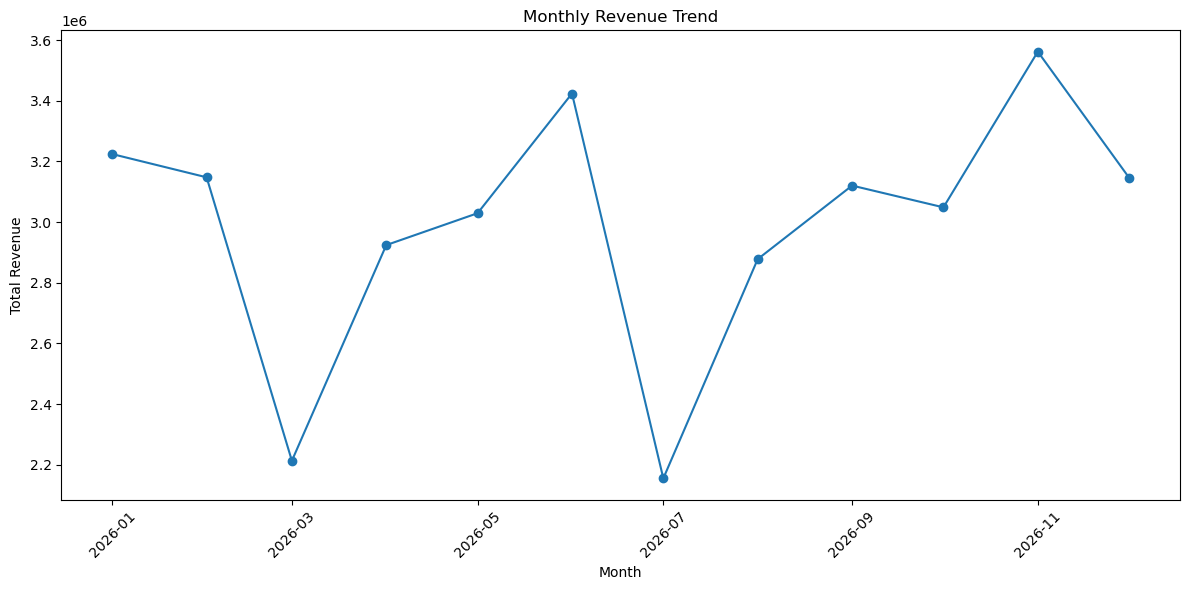

In [72]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales["Total_Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Insights

### 🔎 1. Highest and lowest revenue months

#### Highest: November — 3,561,800

#### Second highest: June — 3,423,900

#### Lowest: July — 2,155,100

#### Second lowest: March — 2,213,200

So there is substantial month-to-month variation.

## 🔎 2. July is particularly interesting

### July had:

#### 33 orders — lowest

#### 69 units — lowest

#### 2.156M revenue — lowest

So July's low revenue is clearly associated with lower sales volume.

That's different from February, where you had 46 orders and 104 units, but revenue was only 3.148M.

This tells us that sales volume and order value both affect revenue.

### 🔎 3. November was your strongest month

November generated:

#### 3.562M revenue

from:

#### 40 orders and 91 units.

Interestingly, October had more orders:

#### 53 orders

but generated only:

#### 3.049M revenue.

This suggests November had higher-value sales, despite having fewer orders.

That's a very useful business insight.   

In [73]:
monthly_sales.sort_values(
    "Total_Revenue",
    ascending=False
).head(5)

,Total_Orders,Total_Quantity,Total_Revenue
Order_Date,,,
2026-11-01,40,91,3561800.0
2026-06-01,35,88,3423900.0
2026-01-01,37,80,3224200.0
2026-02-01,46,104,3147600.0
2026-12-01,43,85,3146000.0


In [74]:
monthly_sales.sort_values(
    "Total_Revenue",
    ascending=True
).head(5)

,Total_Orders,Total_Quantity,Total_Revenue
Order_Date,,,
2026-07-01,33,69,2155100.0
2026-03-01,38,72,2213200.0
2026-08-01,44,85,2877900.0
2026-04-01,42,88,2924200.0
2026-05-01,47,93,3029300.0


In [75]:
monthly_sales["AOV"] = (
    monthly_sales["Total_Revenue"] /
    monthly_sales["Total_Orders"]
)

monthly_sales.round(2)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Order_Date,,,,
2026-01-01,37,80,3224200.0,87140.54
2026-02-01,46,104,3147600.0,68426.09
2026-03-01,38,72,2213200.0,58242.11
2026-04-01,42,88,2924200.0,69623.81
2026-05-01,47,93,3029300.0,64453.19
2026-06-01,35,88,3423900.0,97825.71
2026-07-01,33,69,2155100.0,65306.06
2026-08-01,44,85,2877900.0,65406.82
2026-09-01,42,86,3120300.0,74292.86


In [76]:
monthly_sales.sort_values(
    "AOV",
    ascending=False
).head(5)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Order_Date,,,,
2026-06-01,35,88,3423900.0,97825.714286
2026-11-01,40,91,3561800.0,89045.000000
2026-01-01,37,80,3224200.0,87140.540541
2026-09-01,42,86,3120300.0,74292.857143
2026-12-01,43,85,3146000.0,73162.790698


In [77]:
monthly_sales.sort_values(
    "AOV",
    ascending=True
).head(5)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
Order_Date,,,,
2026-10-01,53,109,3048600.0,57520.754717
2026-03-01,38,72,2213200.0,58242.105263
2026-05-01,47,93,3029300.0,64453.191489
2026-07-01,33,69,2155100.0,65306.060606
2026-08-01,44,85,2877900.0,65406.818182


## 📊 Monthly Sales Analysis
### 1. Highest AOV months
Month	AOV
June	97,826
November	89,045
January	87,141
September	74,293
December	73,163

June has the highest AOV, even though it only had 35 orders. This means June's strong revenue was driven primarily by high-value orders, rather than high order volume.

### 2. Lowest AOV months
Month	AOV
October	57,521
March	58,242
May	64,453
July	65,306
August	65,407

October is particularly interesting: it had the highest number of orders (53) but one of the lowest AOVs (57,521).

So:

October = high volume, lower-value orders.

Whereas:

June = low volume, high-value orders.

That's a valuable business insight.

### 🔎 3. Revenue vs AOV vs Order Volume

Let's look at the most interesting months:

🟢 June
Orders: 35
Quantity: 88
Revenue: 3.424M
AOV: 97,826

High AOV → high revenue despite relatively few orders.

🔵 October
Orders: 53 ← highest
Quantity: 109 ← highest
Revenue: 3.049M
AOV: 57,521 ← low

High volume but low AOV.

🟣 November
Orders: 40
Quantity: 91
Revenue: 3.562M ← highest
AOV: 89,045

This is probably your best overall month because it combines relatively strong volume with high-value orders.

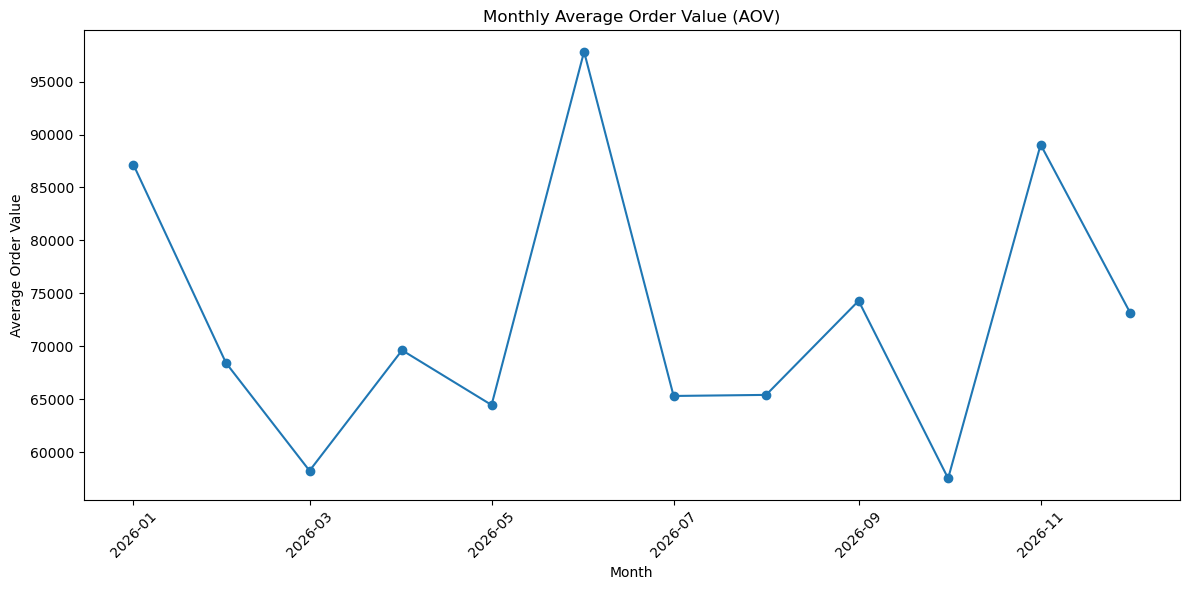

In [78]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales["AOV"],
    marker="o"
)

plt.title("Monthly Average Order Value (AOV)")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion
Monthly Sales Insight: Sales performance varied considerably throughout 2026. November recorded the highest monthly revenue at 3.56M, while July recorded the lowest at 2.16M. June achieved the highest AOV (97,826), indicating that its strong revenue was driven by high-value orders despite relatively low order volume. In contrast, October had the highest number of orders (53) but one of the lowest AOVs (57,521), demonstrating that high order volume does not necessarily translate into the highest revenue.

In [79]:
monthly_product_sales=(
    df.groupby([
        df["Order_Date"].dt.to_period("M"),
        "Product"
    ])["Revenue"]
    .sum()
    .unstack(fill_value=0)
)

monthly_product_sales
    

Product,Desk,Headphones,Keyboard,Laptop,Mobile,Monitor,Mouse,Office Chair
Order_Date,,,,,,,,
2026-01,186800.0,8200.0,18100.0,1555900.0,1063900.0,301200.0,43700.0,46400.0
2026-02,469600.0,103900.0,64000.0,1691200.0,441500.0,180600.0,47100.0,149700.0
2026-03,330800.0,103400.0,49100.0,938500.0,651400.0,55400.0,20000.0,64600.0
2026-04,387400.0,121900.0,23600.0,1050600.0,608600.0,540700.0,12800.0,178600.0
2026-05,222700.0,142100.0,72300.0,1428500.0,1023800.0,91900.0,27600.0,20400.0
2026-06,136400.0,202400.0,56800.0,2083900.0,752400.0,186600.0,5400.0,0.0
2026-07,261300.0,99900.0,41400.0,845100.0,612700.0,141500.0,17000.0,136200.0
2026-08,202500.0,81700.0,44700.0,1385500.0,565800.0,504600.0,27400.0,65700.0
2026-09,83400.0,106400.0,50800.0,917300.0,1423600.0,342900.0,4800.0,191100.0


## 📊 Product × Month Revenue Analysis

### 1. Laptop is the main revenue driver

Laptop generated the highest revenue in most months and reached its annual high in June: 2.084M.

It also performed strongly in:

#### February: 1.691M

#### December: 1.763M

#### January: 1.556M

This confirms that Laptop is the core revenue-generating product in your dataset.

### 2. Mobile has an interesting pattern

Mobile's strongest month was September: 1.424M.

That's particularly interesting because September was not the highest overall revenue month.

Mobile also performed strongly in:

#### January: 1.064M

#### May: 1.024M

#### November: 1.130M

So Mobile can make a significant contribution even when Laptop sales are weaker.

### 3. March's revenue decline is mainly a Laptop issue

Remember that March had only 2.213M total revenue, one of your weakest months.

Laptop revenue fell to:

#### 938,500

compared with:

#### 1,691,200 in February

That's a decline of approximately 44.5%.

Mobile actually increased from 441,500 → 651,400, so the March decline wasn't caused by Mobile.

This gives us a much stronger explanation for the March downturn.

### 4. July was another weak month

July had only 2.155M total revenue.

Laptop revenue was:

#### 845,100

and Mobile:

#### 612,700

Both were relatively weak compared with their stronger months.

So July's low overall revenue appears to be associated with lower performance from the two major revenue drivers.

### 5. November's record revenue is especially interesting

November had the highest total monthly revenue: 3.562M.

The biggest contributors were:

#### Laptop → 1.281M

#### Mobile → 1.130M

#### Desk → 653,500

So November wasn't dependent on Laptop alone. Mobile and Desk also contributed strongly, creating a more balanced high-revenue month.

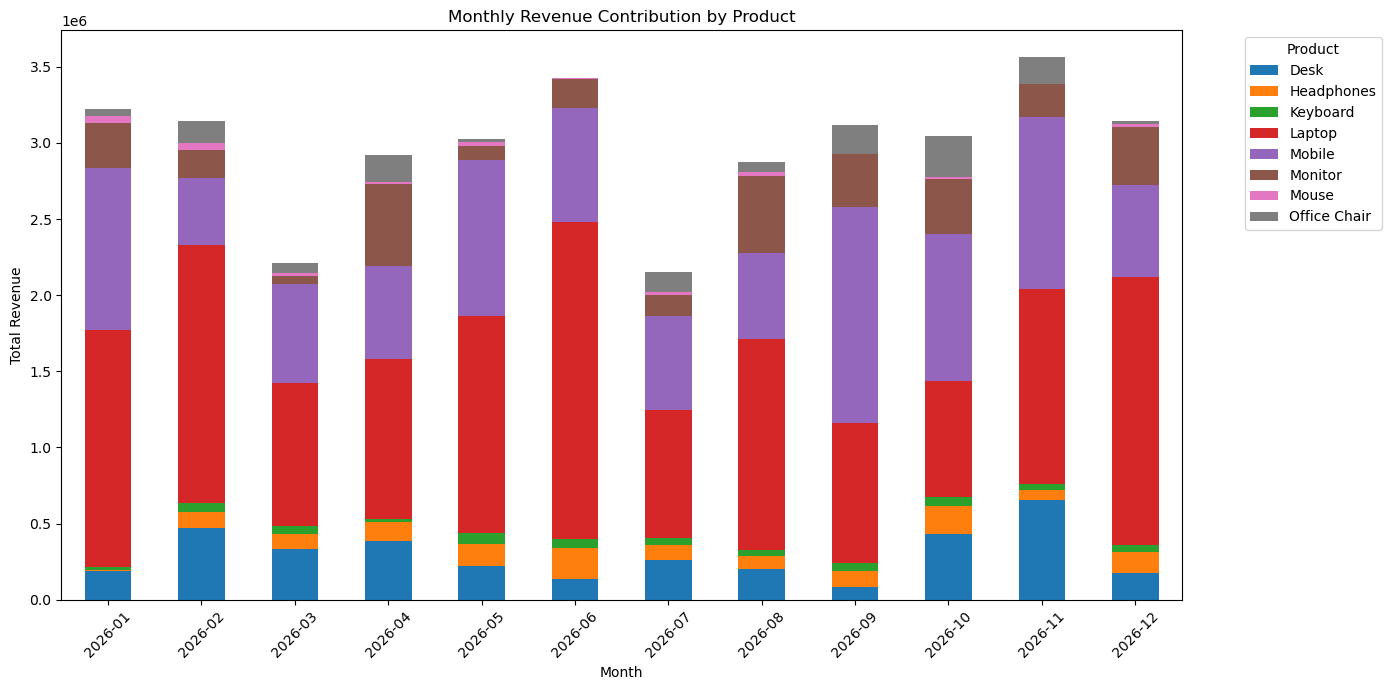

In [80]:
monthly_product_sales.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7)
)

plt.title("Monthly Revenue Contribution by Product")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend(title="Product", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()
    

Product-Month Insight: Laptop remained the primary revenue driver throughout 2026, while Mobile provided a strong secondary contribution. The revenue declines observed in March and July were largely associated with weaker performance from these major products. November achieved the highest monthly revenue, supported not only by Laptop and Mobile but also by a strong contribution from Desk sales.

In [81]:
monthly_top_product=monthly_product_sales.idxmax(axis=1)

monthly_top_product

Order_Date
2026-01    Laptop
2026-02    Laptop
2026-03    Laptop
2026-04    Laptop
2026-05    Laptop
2026-06    Laptop
2026-07    Laptop
2026-08    Laptop
2026-09    Mobile
2026-10    Mobile
2026-11    Laptop
2026-12    Laptop
Freq: M, dtype: object

In [82]:
monthly_top_revenue=monthly_product_sales.max(axis=1)

monthly_top_revenue

Order_Date
2026-01    1555900.0
2026-02    1691200.0
2026-03     938500.0
2026-04    1050600.0
2026-05    1428500.0
2026-06    2083900.0
2026-07     845100.0
2026-08    1385500.0
2026-09    1423600.0
2026-10     964400.0
2026-11    1280700.0
2026-12    1762700.0
Freq: M, dtype: float64

In [83]:
monthly_top_product_summary=pd.DataFrame({
    "Top_Product": monthly_top_product,
    "Revenue": monthly_top_revenue
})

monthly_top_product_summary

,Top_Product,Revenue
Order_Date,,
2026-01,Laptop,1555900.0
2026-02,Laptop,1691200.0
2026-03,Laptop,938500.0
2026-04,Laptop,1050600.0
2026-05,Laptop,1428500.0
2026-06,Laptop,2083900.0
2026-07,Laptop,845100.0
2026-08,Laptop,1385500.0
2026-09,Mobile,1423600.0


### Conclusion:

Product-Month Insight: Laptop was the leading revenue-generating product in 10 out of 12 months, demonstrating its importance to overall business revenue. Mobile became the top-performing product in September and October. Laptop revenue peaked in June at 2.08M, while its weaker performance in March and July contributed significantly to the overall revenue declines during those months.

## Payment Method Analysis

In [84]:
payment_method_summary=(
    df.groupby("Payment_Method")
    .agg(
        Total_Orders=("Order_ID","nunique"),
        Total_Revenue=("Revenue","sum")
    )
    .sort_values("Total_Revenue",ascending=False)
)

payment_method_summary
    

,Total_Orders,Total_Revenue
Payment_Method,,
Online,168,13349500.0
Card,149,9872300.0
Cash,131,9048900.0
Bank Transfer,48,3225800.0
Unknown,4,375600.0


## 🔎 Key insights

### 1. Online is the leading payment method

Online payments generated 13.35M, the highest revenue among all payment methods.

They also had the highest number of orders: 168.

### 2. Card and Cash are also significant

Card generated 9.87M, while Cash generated 9.05M.

Together, these three methods account for the vast majority of your sales.

### 3. Bank Transfer has relatively low usage

Only 48 orders used Bank Transfer, generating 3.23M.

### 4. Unknown payment data should be investigated

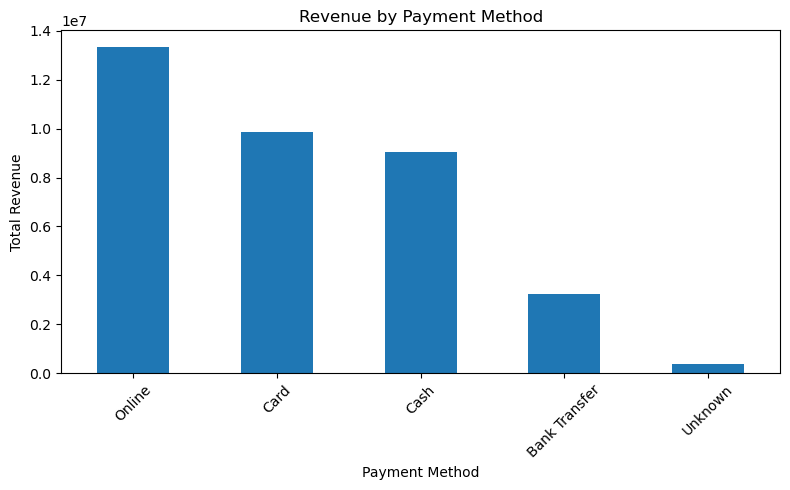

In [85]:
payment_method_summary["Total_Revenue"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Order Status Analysis

In [86]:
order_status_summary=(
    df.groupby("Order_Status")
    .agg(
        Total_Orders=("Order_ID", "nunique"),
        Total_Revenue=("Revenue", "sum")
      )
      .sort_values("Total_Orders", ascending=False)
)

order_status_summary

,Total_Orders,Total_Revenue
Order_Status,,
Completed,434,32209100.0
Cancelled,37,2247000.0
Returned,29,1416000.0


## 🔎 Key insights

### 1. Most orders are completed

You have 434 completed orders out of 500 total orders, meaning approximately 86.8% of orders were completed.

That's a strong completion rate.

### 2. Cancellation rate

37 orders were cancelled:

#### 37 / 500 = 7.4%

So approximately 7.4% of orders were cancelled.

### 3. Return rate

29 orders were returned:

#### 29 / 500 = 5.8%

So approximately 5.8% of orders were returned.

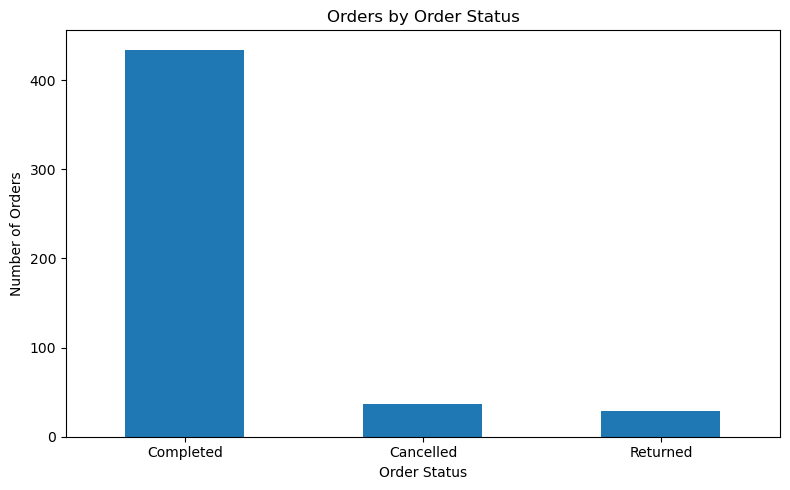

In [87]:
order_status_summary["Total_Orders"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Orders by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [88]:
completed_revenue = df.loc[
    df["Order_Status"] == "Completed",
    "Revenue"
].sum()

gross_revenue = df["Revenue"].sum()

print("Gross Revenue:", gross_revenue)
print("Completed Revenue:", completed_revenue)
print(
    "Revenue from Cancelled/Returned Orders:",
    gross_revenue - completed_revenue
)

Gross Revenue: 35872100.0
Completed Revenue: 32209100.0
Revenue from Cancelled/Returned Orders: 3663000.0


In [89]:
non_completed_pct = (
    (gross_revenue - completed_revenue) / gross_revenue
) * 100

print(f"Non-completed revenue percentage: {non_completed_pct:.2f}%")

Non-completed revenue percentage: 10.21%


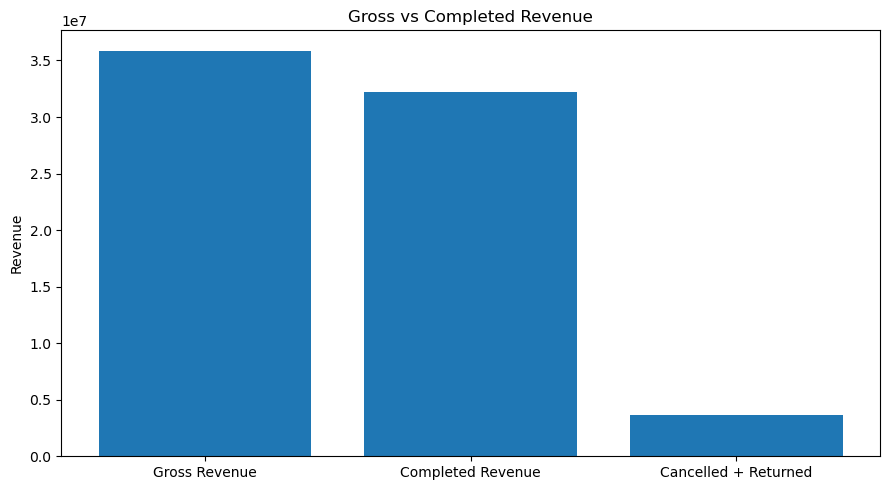

In [90]:
revenue_comparison = pd.Series({
    "Gross Revenue": gross_revenue,
    "Completed Revenue": completed_revenue,
    "Cancelled + Returned": gross_revenue - completed_revenue
})

plt.figure(figsize=(9, 5))

plt.bar(
    revenue_comparison.index,
    revenue_comparison.values
)

plt.title("Gross vs Completed Revenue")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

### Conclusion:
The dataset records 35.87M in gross revenue, while completed orders account for 32.21M. Approximately 3.66M (10.21%) of recorded revenue is associated with cancelled or returned orders. Therefore, completed revenue provides a more reliable measure of realized sales performance than gross recorded revenue.

## City_Based Analysis

In [91]:
city_summary = (
    df.groupby("City")
      .agg(
          Total_Orders=("Order_ID", "nunique"),
          Total_Quantity=("Quantity", "sum"),
          Total_Revenue=("Revenue", "sum")
      )
      .sort_values("Total_Revenue", ascending=False)
)

city_summary

,Total_Orders,Total_Quantity,Total_Revenue
City,,,
Islamabad,81,179,6717200.0
Multan,81,176,6625500.0
Karachi,77,159,5559400.0
Faisalabad,64,136,4721300.0
Lahore,80,159,4403400.0
Rawalpindi,61,127,4272900.0
Peshawar,52,104,3368300.0
Unknown,4,10,204100.0


## 🔎 Key insights

### 🥇 Islamabad is the highest-revenue city

Islamabad generated 6.72M, slightly ahead of Multan at 6.63M.

Interestingly, both cities have exactly 81 orders, so Islamabad's higher revenue comes from higher-value orders/products.

### 🥈 Multan is a very strong market

Multan generated 6.63M from 81 orders, making it almost equal to Islamabad.

### Karachi is third

Karachi generated 5.56M from 77 orders, showing strong overall performance despite having fewer orders than Islamabad and Multan.

### Lahore is an interesting case

Lahore had 80 orders, almost as many as Islamabad's 81, but generated only 4.40M compared with Islamabad's 6.72M.

This suggests a substantial difference in average order value.

In [92]:
city_summary["AOV"] = (
    city_summary["Total_Revenue"] /
    city_summary["Total_Orders"]
)

city_summary.sort_values(
    "AOV",
    ascending=False
)

,Total_Orders,Total_Quantity,Total_Revenue,AOV
City,,,,
Islamabad,81,179,6717200.0,82928.395062
Multan,81,176,6625500.0,81796.296296
Faisalabad,64,136,4721300.0,73770.312500
Karachi,77,159,5559400.0,72200.000000
Rawalpindi,61,127,4272900.0,70047.540984
Peshawar,52,104,3368300.0,64775.000000
Lahore,80,159,4403400.0,55042.500000
Unknown,4,10,204100.0,51025.000000


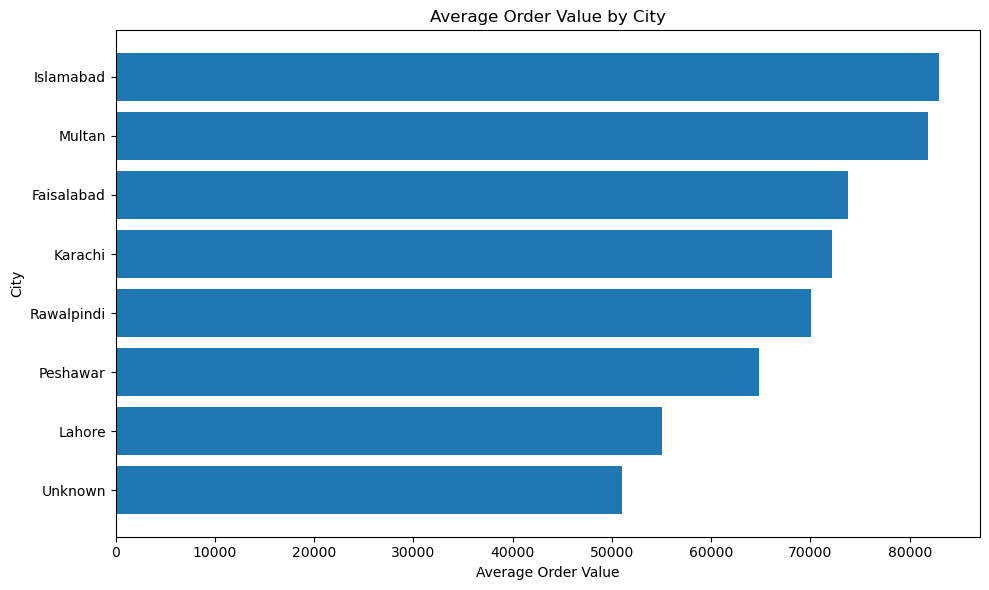

In [93]:
city_aov = city_summary.sort_values("AOV")

plt.figure(figsize=(10, 6))

plt.barh(
    city_aov.index,
    city_aov["AOV"]
)

plt.title("Average Order Value by City")
plt.xlabel("Average Order Value")
plt.ylabel("City")

plt.tight_layout()
plt.show()

## Final KPIs

In [94]:
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
gross_revenue = df["Revenue"].sum()

completed_orders = df.loc[
    df["Order_Status"] == "Completed",
    "Order_ID"
].nunique()

cancelled_orders = df.loc[
    df["Order_Status"] == "Cancelled",
    "Order_ID"
].nunique()

returned_orders = df.loc[
    df["Order_Status"] == "Returned",
    "Order_ID"
].nunique()

completed_revenue = df.loc[
    df["Order_Status"] == "Completed",
    "Revenue"
].sum()

overall_aov = gross_revenue / total_orders
completion_rate = completed_orders / total_orders * 100
cancellation_rate = cancelled_orders / total_orders * 100
return_rate = returned_orders / total_orders * 100

print("Total Orders:", total_orders)
print("Total Quantity:", total_quantity)
print("Gross Revenue:", gross_revenue)
print("Completed Revenue:", completed_revenue)
print("Overall AOV:", round(overall_aov, 2))
print("Completion Rate:", round(completion_rate, 2), "%")
print("Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Return Rate:", round(return_rate, 2), "%")

Total Orders: 500
Total Quantity: 1050
Gross Revenue: 35872100.0
Completed Revenue: 32209100.0
Overall AOV: 71744.2
Completion Rate: 86.8 %
Cancellation Rate: 7.4 %
Return Rate: 5.8 %


In [95]:
top_product = product_summary["Total_Revenue"].idxmax()
top_customer = customer_summary["Total_Revenue"].idxmax()
top_city = city_summary["Total_Revenue"].idxmax()
top_payment = payment_method_summary["Total_Revenue"].idxmax()

print("Top Product:", top_product)
print("Top Customer:", top_customer)
print("Top City:", top_city)
print("Top Payment Method:", top_payment)

Top Product: Laptop
Top Customer: C1116
Top City: Islamabad
Top Payment Method: Online


## Key Findings
### 1. 💻 Laptop is the dominant product

Laptop generated 15.71M, making it the strongest revenue-generating product.

It also generated the highest revenue per unit at approximately 85,365.

### Recommendation: 
Protect laptop inventory and consider targeted promotions, bundles, and cross-selling around this product.

### 2. 📱 Mobile is the strongest alternative product

Mobile generated 9.85M and became the highest-revenue product in September and October, when Laptop wasn't #1.

### Recommendation: 
Mobile should be treated as an important secondary revenue driver rather than relying exclusively on Laptop.

### 3. 👑 High-value customers are significantly more valuable

Your customer segmentation showed:

#### Segment	Avg     Revenue	   Avg AOV

#### Low Value	    77,418	   40,874

#### Medium Value    207,477	   68,628

#### High Value	    451,422	   110,463

High-value customers generate approximately 5.8× the revenue of low-value customers on average.

### Recommendation: 
Develop loyalty programs, personalized offers, and retention campaigns for high-value customers.

### 4. 📈 Revenue fluctuates considerably by month

### Highest revenue: November → 3.56M

### Lowest revenue: July → 2.16M

June had the highest AOV at 97,826, while October had the lowest at 57,521.

This shows that revenue depends on both order volume and order value.

### 5. 💳 Online payment is the leading payment method

Online payments generated 13.35M across 168 orders, making it the leading payment method.

### Recommendation: 
Continue optimizing the online checkout experience while maintaining strong alternatives such as card and cash.

### 6. 📦 Most orders are completed

Your completion rate is 86.8%.

However:

### Cancellation rate = 7.4%

### Return rate = 5.8%

Together, cancelled and returned orders represent 13.2% of orders.

More importantly, 3.66M of recorded revenue is associated with cancelled or returned orders.

### Recommendation: 
Investigate the causes of cancellations and returns, especially for high-revenue products.

### 7. 🏙️ Islamabad is the strongest city

Islamabad generated 6.72M from 81 orders.

Multan was very close at 6.63M, followed by Karachi at 5.56M.

### Recommendation: 
Consider Islamabad and Multan priority markets for targeted marketing and customer-retention campaigns.

## Final Conclusion

This exploratory data analysis examined 500 orders, 1,050 units sold, and 35.87 million in recorded gross revenue. Overall, the business demonstrated strong sales activity, with 86.8% of orders completed and an overall average order value of 71,744.

Product analysis showed that **Laptop** was the strongest revenue-generating product, contributing 15.71 million in revenue and achieving the highest revenue per unit. **Mobile** was the second-largest contributor and became the leading product in September and October, highlighting its importance as an alternative revenue driver.

Customer analysis revealed a clear difference between customer segments. High-value customers generated substantially more revenue and had higher average order values than medium- and low-value customers. The moderate positive correlation of **0.655 between AOV and total customer revenue** suggests that both spending per order and purchase frequency contribute to customer value.

Time-based analysis showed considerable monthly variation. **November recorded the highest monthly revenue at 3.56 million**, while **July recorded the lowest at 2.16 million**. June achieved the highest monthly AOV, indicating that high-value orders can drive revenue even when order volume is relatively low.

Geographic analysis identified **Islamabad as the highest-revenue city**, followed closely by Multan and Karachi. Online payments were the leading payment method, generating 13.35 million in revenue.

Order-status analysis showed an **86.8% completion rate**, with 7.4% of orders cancelled and 5.8% returned. Approximately **3.66 million** of recorded revenue was associated with cancelled or returned orders, highlighting the importance of distinguishing gross recorded revenue from completed revenue when evaluating actual sales performance.

Overall, the analysis suggests that the business should focus on protecting its high-performing Laptop and Mobile product categories, retaining high-value customers, strengthening high-performing geographic markets, improving online purchasing experiences, and investigating the causes of cancellations and returns. These actions could help improve both revenue growth and overall sales quality.


## Business Recommendations

For your portfolio, I'd include these 5 recommendations:

### 1. Protect high-performing products
Prioritize Laptop and Mobile inventory, marketing, and cross-selling opportunities.

### 2. Retain high-value customers
Create loyalty programs and personalized promotions for high-value customers.

### 3. Investigate cancellations and returns
Analyze why orders are cancelled or returned, particularly for high-value products.

### 4. Target high-performing markets
Focus marketing efforts on Islamabad, Multan, and Karachi while investigating why Lahore generates lower revenue despite high order volume.

### 5. Optimize order value
Use product bundles, upselling, and cross-selling to increase AOV, particularly during lower-AOV months.